In [1]:
import sys
import os
os.chdir("/home/felixpersson/MasterThesisProject")
print(os.getcwd())

/home/felixpersson/MasterThesisProject


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import json

from models.fuel_pin.fuel_pin_model import FuelPin
import data.dataclass as d_class

%config InlineBackend.figure_format = "retina"

FuelPinGeometry(l=1.5, r=0.015, delta_gap=0.003, delta_wall=0.003)
FuelPinGeometry(l=1.5, r=0.015, delta_gap=0.003, delta_wall=0.003)
Total generated power: 10000.000000 W


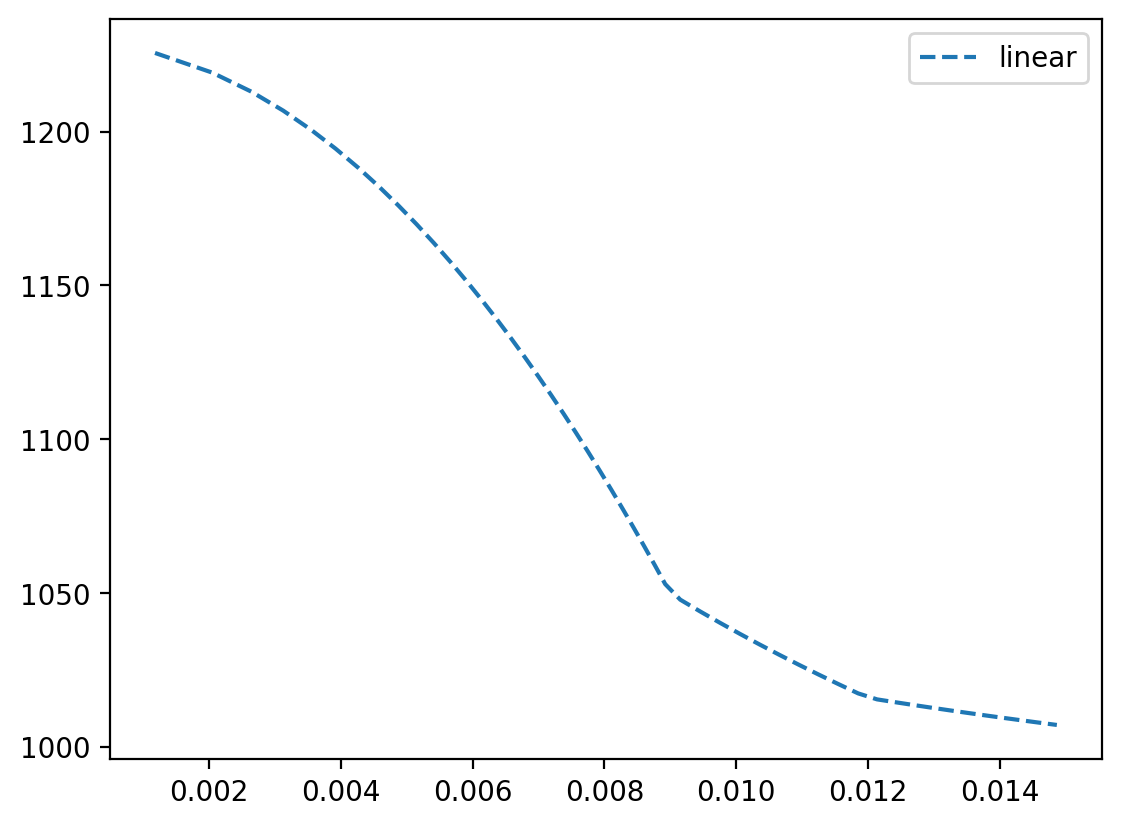

In [4]:
with open("data/fuelpin_validation.json", "r") as f:
    data = json.load(f)["FuelPin"]

N_Z = 10
N_R = 50

geom   = d_class.FuelPinGeometry(**data["geometry"])
mesh   = d_class.FuelPinMesh(N_Z=N_Z, N_R=N_R)
energy = d_class.FuelPinEnergy(**data["energy"])
mat    = d_class.FuelPinMaterial(**data["material"])
cfg    = d_class.FuelPinConfig(geom, mesh, energy, mat)

print(geom)

cfg = cfg.resolve_mesh()

print(cfg.geometry)

fuel_pin = FuelPin(cfg)
fuel_pin.variable_k = False

# Normalize total generated power by scaling kappa
P_target = 10000.0  # W

P_current = np.sum(fuel_pin.qr) * fuel_pin.cfg.mesh.N_fuel

if P_current <= 0.0:
    raise ValueError("Current generated power is zero or negative; cannot normalize kappa.")

fuel_pin.kappa *= P_target / P_current

# Recompute qr using the rescaled kappa
fuel_pin.calculate_qr()

# Optional check
P_check = np.sum(fuel_pin.qr) * fuel_pin.cfg.mesh.N_fuel
print(f"Total generated power: {P_check:.6f} W")

fuel_pin.linear_solve()

plt.plot(fuel_pin.R, fuel_pin.T.reshape(cfg.mesh.N_Z, cfg.mesh.N_R)[0], ls="--", label="linear")

plt.legend()
plt.show()

In [5]:
def analytical_layered_fuel_pin_temperature(
    r,
    R_fuel,
    R_gap,
    R_clad,
    L,
    P_total=None,
    q_vol=None,
    k_fuel=1.0,
    k_gap=1.0,
    k_clad=1.0,
    h_mod=np.inf,
    T_mod=1000.0,
):
    """
    Analytical radial temperature profile for a cylindrical layered fuel pin.

    Regions
    -------
    0 <= r <= R_fuel:
        Fuel with constant volumetric heat generation q'''.

    R_fuel < r <= R_gap:
        Gap with no heat generation.

    R_gap < r <= R_clad:
        Cladding with no heat generation.

    Boundary conditions
    -------------------
    dT/dr = 0 at r = 0
    -k_clad dT/dr = h_mod (T_surface - T_mod) at r = R_clad

    Parameters
    ----------
    r : array_like
        Radial positions where the temperature is evaluated [m].
    R_fuel : float
        Outer fuel radius [m].
    R_gap : float
        Outer gap radius [m].
    R_clad : float
        Outer cladding radius [m].
    L : float
        Axial length of the pin [m].
    P_total : float, optional
        Total generated fuel power [W].
    q_vol : float, optional
        Volumetric heat generation in the fuel [W/m^3].
        If given, this is used directly. Otherwise, P_total is used.
    k_fuel : float
        Fuel thermal conductivity [W/(m K)].
    k_gap : float
        Gap effective thermal conductivity [W/(m K)].
    k_clad : float
        Cladding thermal conductivity [W/(m K)].
    h_mod : float
        Convective heat-transfer coefficient at the outer cladding surface [W/(m^2 K)].
        Use np.inf for prescribed surface temperature T(R_clad) = T_mod.
    T_mod : float
        Moderator / coolant temperature [K].

    Returns
    -------
    T : ndarray
        Temperature evaluated at the radial positions r [K].
    """

    r = np.asarray(r, dtype=float)

    if not (0.0 < R_fuel < R_gap < R_clad):
        raise ValueError("Require 0 < R_fuel < R_gap < R_clad.")

    if np.any(r < 0.0) or np.any(r > R_clad):
        raise ValueError("Radial positions must satisfy 0 <= r <= R_clad.")

    if k_fuel <= 0.0 or k_gap <= 0.0 or k_clad <= 0.0:
        raise ValueError("All thermal conductivities must be positive.")

    if h_mod <= 0.0:
        raise ValueError("h_mod must be positive.")

    if q_vol is None:
        if P_total is None:
            raise ValueError("Either P_total or q_vol must be provided.")

        V_fuel = np.pi * R_fuel**2 * L
        q_vol = P_total / V_fuel

    T = np.empty_like(r)

    # Useful factor appearing in the non-generating cylindrical layers
    A = q_vol * R_fuel**2 / 2.0

    # Outer cladding surface temperature from convection
    if np.isinf(h_mod):
        T_clad_outer = T_mod
    else:
        T_clad_outer = T_mod + A / (h_mod * R_clad)

    # Temperature at gap/clad interface
    T_gap_outer = T_clad_outer + A / k_clad * np.log(R_clad / R_gap)

    # Temperature at fuel/gap interface
    T_fuel_outer = T_gap_outer + A / k_gap * np.log(R_gap / R_fuel)

    # Region masks
    fuel_mask = r <= R_fuel
    gap_mask = (r > R_fuel) & (r <= R_gap)
    clad_mask = r > R_gap

    # Fuel region
    T[fuel_mask] = (
        T_fuel_outer
        + q_vol / (4.0 * k_fuel) * (R_fuel**2 - r[fuel_mask]**2)
    )

    # Gap region
    T[gap_mask] = (
        T_gap_outer
        + A / k_gap * np.log(R_gap / r[gap_mask])
    )

    # Cladding region
    T[clad_mask] = (
        T_clad_outer
        + A / k_clad * np.log(R_clad / r[clad_mask])
    )

    return T

In [6]:
# Make sure the linear numerical solution exists
fuel_pin.linear_solve()

T_linear = fuel_pin.T.reshape(cfg.mesh.N_Z, cfg.mesh.N_R)

# Extract total generated power from the numerical model
P_total = np.sum(fuel_pin.qr) * cfg.mesh.N_fuel

print(f"Total generated power: {P_total:.6f} W")

# Extract layer boundaries from the actual fuel-pin discretisation
R_outer_edges = fuel_pin.surface_tensor[0, :, 0] / (2.0 * np.pi * fuel_pin.Delta_Z)

R_fuel = R_outer_edges[cfg.mesh.N_fuel - 1]
R_gap  = R_outer_edges[cfg.mesh.N_fuel + cfg.mesh.N_gap - 1]
R_clad = R_outer_edges[-1]

# Extract the same material properties used by the linear model
k_matrix = fuel_pin.generate_k_matrix()

k_fuel = np.mean(k_matrix[0, :cfg.mesh.N_fuel])
k_gap  = np.mean(k_matrix[0, cfg.mesh.N_fuel:cfg.mesh.N_fuel + cfg.mesh.N_gap])
k_clad = np.mean(k_matrix[0, cfg.mesh.N_fuel + cfg.mesh.N_gap:])

h_mod = fuel_pin.generate_h_matrix()[0, -1]

# Print dimensions and material parameters used in the analytical comparison
print("\n--- Fuel-pin analytical validation parameters ---")
print(f"N_Z:        {cfg.mesh.N_Z}")
print(f"N_R:        {cfg.mesh.N_R}")
print(f"N_fuel:     {cfg.mesh.N_fuel}")
print(f"N_gap:      {cfg.mesh.N_gap}")
print(f"N_clad:     {cfg.mesh.N_R - cfg.mesh.N_fuel - cfg.mesh.N_gap}")

print("\nGeometry:")
print(f"Pin length, L:              {cfg.geometry.l:.6e} m")
print(f"Fuel outer radius, R_fuel:  {R_fuel:.6e} m")
print(f"Gap outer radius, R_gap:    {R_gap:.6e} m")
print(f"Clad outer radius, R_clad:  {R_clad:.6e} m")
print(f"Gap thickness:              {(R_gap - R_fuel):.6e} m")
print(f"Clad thickness:             {(R_clad - R_gap):.6e} m")

print("\nMaterial / thermal parameters:")
print(f"Fuel conductivity, k_fuel:  {k_fuel:.6e} W/(m K)")
print(f"Gap conductivity, k_gap:    {k_gap:.6e} W/(m K)")
print(f"Clad conductivity, k_clad:  {k_clad:.6e} W/(m K)")
print(f"Moderator HTC, h_mod:       {h_mod:.6e} W/(m^2 K)")
print(f"Moderator temperature:      {fuel_pin.T_mod[0]:.6e} K")

print("\nPower:")
print(f"Total generated power:      {P_total:.6e} W")
print(f"Fuel volume:                {np.pi * R_fuel**2 * cfg.geometry.l:.6e} m^3")
print(f"Volumetric heat generation: {P_total / (np.pi * R_fuel**2 * cfg.geometry.l):.6e} W/m^3")
print("-----------------------------------------------\n")

# Analytical layered solution evaluated at the numerical cell centres
T_analytical = analytical_layered_fuel_pin_temperature(
    r=fuel_pin.R,
    R_fuel=R_fuel,
    R_gap=R_gap,
    R_clad=R_clad,
    L=cfg.geometry.l,
    P_total=P_total,
    k_fuel=k_fuel,
    k_gap=k_gap,
    k_clad=k_clad,
    h_mod=h_mod,
    T_mod=fuel_pin.T_mod[0],
)

# Choose one axial slice for comparison
z_idx = 0

Total generated power: 10000.000000 W

--- Fuel-pin analytical validation parameters ---
N_Z:        10
N_R:        50
N_fuel:     29
N_gap:      10
N_clad:     11

Geometry:
Pin length, L:              1.500000e+00 m
Fuel outer radius, R_fuel:  9.000000e-03 m
Gap outer radius, R_gap:    1.200000e-02 m
Clad outer radius, R_clad:  1.500000e-02 m
Gap thickness:              3.000000e-03 m
Clad thickness:             3.000000e-03 m

Material / thermal parameters:
Fuel conductivity, k_fuel:  2.971784e+00 W/(m K)
Gap conductivity, k_gap:    8.999996e+00 W/(m K)
Clad conductivity, k_clad:  2.586898e+01 W/(m K)
Moderator HTC, h_mod:       1.000000e+04 W/(m^2 K)
Moderator temperature:      1.000000e+03 K

Power:
Total generated power:      1.000000e+04 W
Fuel volume:                3.817035e-04 m^3
Volumetric heat generation: 2.619834e+07 W/m^3
-----------------------------------------------



In [7]:
import matplotlib.tri as mtri

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "font.size": 30,
    "text.usetex": True,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "0.7",
})

colors = {
    "black": "#000000",
    "blue": "#0072B2",
    "cyan": "#56B4E9",
    "green": "#009E73",
    "orange": "#E69F00",
    "red": "#D55E00",
    "magenta": "#CC79A7",
    "yellow": "#F0E442"
}

def _apply_thesis_grid(ax):
    ax.minorticks_on()

    ax.grid(
        which="major",
        alpha=0.35,
        linewidth=0.8,
        zorder=0,
    )

    ax.grid(
        which="minor",
        alpha=0.18,
        linewidth=0.45,
        zorder=0,
    )

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
    )

    ax.tick_params(which="major", length=6, width=1.0)
    ax.tick_params(which="minor", length=3, width=0.8)


def plot_fuel_pin_layered_validation(
    fuel_pin,
    cfg,
    T_numerical=None,
    z_idx=0,
    P_total=None,
    save_path=None,
    show=True,
):
    """
    Thesis-style validation plot comparing the numerical fuel-pin solution
    against the layered analytical cylindrical solution.

    The analytical model assumes:
        - heat generation only in the fuel,
        - constant volumetric heat generation,
        - constant material conductivities,
        - radial conduction through fuel, gap, and clad,
        - convection at the outer cladding surface.

    Parameters
    ----------
    fuel_pin : FuelPin
        FuelPin model instance.

    cfg : FuelPinConfigResolved
        Resolved fuel-pin configuration.

    T_numerical : np.ndarray | None
        Optional numerical temperature array with shape (N_Z, N_R) or flattened.
        If None, fuel_pin.T is used. If fuel_pin.T does not exist, linear_solve()
        is called.

    z_idx : int
        Axial slice used for the radial comparison.

    P_total : float | None
        Total generated fuel power [W]. If None, it is computed from fuel_pin.qr.

    save_path : str | None
        Optional path for saving the figure.

    show : bool
        If True, show the figure.

    Returns
    -------
    fig, (ax, ax_res), metrics : tuple
        Figure, axes, and dictionary with RMSE and maximum absolute error.
    """

    # ------------------------------------------------------------------
    # Numerical solution
    # ------------------------------------------------------------------
    if T_numerical is None:
        if not hasattr(fuel_pin, "T"):
            fuel_pin.linear_solve()

        T_numerical = fuel_pin.T

    T_numerical = np.asarray(T_numerical, dtype=float)

    if T_numerical.ndim == 1:
        T_numerical = T_numerical.reshape(cfg.mesh.N_Z, cfg.mesh.N_R)

    if T_numerical.shape != (cfg.mesh.N_Z, cfg.mesh.N_R):
        raise ValueError(
            "Expected T_numerical with shape "
            f"({cfg.mesh.N_Z}, {cfg.mesh.N_R}), got {T_numerical.shape}."
        )

    r = np.asarray(fuel_pin.R, dtype=float)
    T_num = T_numerical[z_idx, :]

    # ------------------------------------------------------------------
    # Geometry
    # ------------------------------------------------------------------
    R_fuel = cfg.geometry.r_fuel
    R_gap = cfg.geometry.r_fuel + cfg.geometry.delta_gap
    R_clad = cfg.geometry.r

    if not np.isclose(R_gap + cfg.geometry.delta_wall, R_clad):
        raise ValueError(
            "Inconsistent geometry: r_fuel + delta_gap + delta_wall "
            "does not match the outer radius."
        )

    # ------------------------------------------------------------------
    # Power
    # ------------------------------------------------------------------
    if P_total is None:
        P_total = np.sum(fuel_pin.qr) * cfg.mesh.N_fuel

    q_vol = P_total / (np.pi * R_fuel**2 * cfg.geometry.l)

    # ------------------------------------------------------------------
    # Material parameters from the same matrix used by the linear model
    # ------------------------------------------------------------------
    k_matrix = fuel_pin.generate_k_matrix()

    fuel_slice = slice(0, cfg.mesh.N_fuel)
    gap_slice = slice(cfg.mesh.N_fuel, cfg.mesh.N_fuel + cfg.mesh.N_gap)
    clad_slice = slice(cfg.mesh.N_fuel + cfg.mesh.N_gap, cfg.mesh.N_R)

    k_fuel = np.mean(k_matrix[z_idx, fuel_slice])
    k_gap = np.mean(k_matrix[z_idx, gap_slice])
    k_clad = np.mean(k_matrix[z_idx, clad_slice])

    h_mod = fuel_pin.generate_h_matrix()[z_idx, -1]
    T_mod = fuel_pin.T_mod[z_idx]

    # ------------------------------------------------------------------
    # Analytical solution
    # ------------------------------------------------------------------
    T_analytical = analytical_layered_fuel_pin_temperature(
        r=r,
        R_fuel=R_fuel,
        R_gap=R_gap,
        R_clad=R_clad,
        L=cfg.geometry.l,
        P_total=P_total,
        k_fuel=k_fuel,
        k_gap=k_gap,
        k_clad=k_clad,
        h_mod=h_mod,
        T_mod=T_mod,
    )

    error = T_num - T_analytical
    rmse = np.sqrt(np.mean(error**2))
    max_abs_error = np.max(np.abs(error))

    metrics = {
        "rmse": rmse,
        "max_abs_error": max_abs_error,
        "P_total": P_total,
        "q_vol": q_vol,
        "k_fuel": k_fuel,
        "k_gap": k_gap,
        "k_clad": k_clad,
        "h_mod": h_mod,
    }

    # Smooth analytical line
    r_line = np.linspace(0.0, R_clad, 800)

    T_analytical_point = analytical_layered_fuel_pin_temperature(
        r=fuel_pin.R,
        R_fuel=R_fuel,
        R_gap=R_gap,
        R_clad=R_clad,
        L=cfg.geometry.l,
        P_total=P_total,
        k_fuel=k_fuel,
        k_gap=k_gap,
        k_clad=k_clad,
        h_mod=h_mod,
        T_mod=T_mod,
    )

    error = T_num - T_analytical_point

    r_line = np.linspace(0.0, R_clad, 800)

    T_line = analytical_layered_fuel_pin_temperature(
        r=r_line,
        R_fuel=R_fuel,
        R_gap=R_gap,
        R_clad=R_clad,
        L=cfg.geometry.l,
        P_total=P_total,
        k_fuel=k_fuel,
        k_gap=k_gap,
        k_clad=k_clad,
        h_mod=h_mod,
        T_mod=T_mod,
    )

    # ------------------------------------------------------------------
    # Figure
    # ------------------------------------------------------------------
    fig, (ax, ax_res) = plt.subplots(
        2,
        1,
        figsize=(13, 10),
        sharex=True,
        constrained_layout=True,
        gridspec_kw={"height_ratios": [3.2, 1.0]},
    )

    fig.set_constrained_layout_pads(
        w_pad=0.08,
        h_pad=0.08,
        hspace=0.06,
    )

    # ------------------------------------------------------------------
    # Main validation plot
    # ------------------------------------------------------------------
    _apply_thesis_grid(ax)

    ax.scatter(
        r,
        T_num,
        s=80,
        marker="o",
        facecolors=colors["blue"],
        edgecolors="none",
        alpha=0.95,
        label=r"Numerical solution",
        zorder=4,
        rasterized=True,
    )

    ax.plot(
        r_line,
        T_line,
        color=colors["red"],
        linewidth=4.0,
        alpha=0.70,
        label=r"Analytical solution",
        zorder=3,
    )

    # Material interfaces
    ax.axvline(
        R_fuel,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax.axvline(
        R_gap,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax.text(
        R_fuel+0.001,
        0.45,
        r"$R_{\mathrm{fuel}}$",
        transform=ax.get_xaxis_transform(),
        ha="right",
        va="bottom",
        fontsize=25,
        rotation=0,
        color="0.1",
    )

    ax.text(
        R_gap+0.001,
        0.45,
        r"$R_{\mathrm{gap}}$",
        transform=ax.get_xaxis_transform(),
        ha="right",
        va="bottom",
        fontsize=25,
        rotation=0,
        color="0.1",
    )

    ax.set_ylabel(r"Temperature $T$ [K]", labelpad=12)

    legend = ax.legend(
        loc="upper right",
        bbox_to_anchor=(0.99, 0.99),
        fontsize=24,
        handlelength=2.2,
        borderpad=0.45,
        labelspacing=0.55,
    )
    legend.set_zorder(10)

    error_text = (
        rf"$\mathrm{{RMSE}} = {rmse:.2e}\,\mathrm{{K}}$"
        "\n"
        rf"$\max(|e|) = {max_abs_error:.2e}\,\mathrm{{K}}$"
    )

    ax.text(
        0.967,
        0.75,
        error_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=22,
        bbox=dict(
            facecolor="white",
            edgecolor=colors["black"],
            boxstyle="round,pad=0.35",
            alpha=0.95,
        ),
        zorder=9,
    )

    # ------------------------------------------------------------------
    # Error plot
    # ------------------------------------------------------------------
    _apply_thesis_grid(ax_res)

    ax_res.axhline(
        0.0,
        color="black",
        linewidth=1.1,
        alpha=0.65,
        zorder=1,
    )

    ax_res.scatter(
        r,
        error,
        s=35,
        marker="o",
        facecolors=colors["green"],
        edgecolors="black",
        linewidths=1.1,
        alpha=0.95,
        zorder=3,
    )

    ax_res.axvline(
        R_fuel,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax_res.axvline(
        R_gap,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax_res.set_xlabel(r"Radius $r$ [m]", labelpad=10)
    ax_res.set_ylabel(r"error $e$ [K]", labelpad=12)

    # ------------------------------------------------------------------
    # Axis limits
    # ------------------------------------------------------------------
    x_pad = 0.025 * R_clad
    ax.set_xlim(0.0 - x_pad, R_clad + x_pad)

    T_all = np.concatenate([T_num, T_line])
    T_min = np.min(T_all)
    T_max = np.max(T_all)
    T_pad = 0.08 * (T_max - T_min) if T_max > T_min else 1.0

    ax.set_ylim(T_min - T_pad, T_max + T_pad)

    e_abs = np.max(np.abs(error))
    e_pad = 0.25 * e_abs if e_abs > 0 else 1.0

    ax_res.set_ylim(
        -e_abs - e_pad,
         e_abs + e_pad,
    )

    fig.align_ylabels([ax, ax_res])

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, (ax, ax_res), metrics

In [10]:
def _faces_from_centres_in_region(r_region, r_inner, r_outer):
    """
    Reconstruct radial cell faces from cell centres inside one material region.

    The material-region endpoints are imposed exactly, while internal faces
    are placed halfway between neighbouring centres.
    """
    r_region = np.asarray(r_region, dtype=float)
    n = len(r_region)

    if n == 0:
        return np.asarray([r_inner, r_outer], dtype=float)

    faces = np.empty(n + 1, dtype=float)
    faces[0] = r_inner
    faces[-1] = r_outer

    if n > 1:
        faces[1:-1] = 0.5 * (r_region[:-1] + r_region[1:])

    return faces


def _get_radial_cell_faces(fuel_pin, cfg, r, R_fuel, R_gap, R_clad):
    """
    Return radial cell faces for the fuel-pin mesh.

    If the model already stores radial faces/edges, those are used.
    Otherwise, faces are reconstructed from cell centres, with exact material
    interfaces at R_fuel and R_gap.
    """

    candidate_names = [
        "r_faces",
        "R_faces",
        "r_edges",
        "R_edges",
        "radial_faces",
        "radial_edges",
    ]

    for obj in [fuel_pin, getattr(cfg, "mesh", None)]:
        if obj is None:
            continue

        for name in candidate_names:
            if hasattr(obj, name):
                faces = np.asarray(getattr(obj, name), dtype=float)

                if faces.ndim == 1 and len(faces) == len(r) + 1:
                    return faces

    N_fuel = cfg.mesh.N_fuel
    N_gap = cfg.mesh.N_gap
    N_R = cfg.mesh.N_R

    fuel_slice = slice(0, N_fuel)
    gap_slice = slice(N_fuel, N_fuel + N_gap)
    clad_slice = slice(N_fuel + N_gap, N_R)

    faces_fuel = _faces_from_centres_in_region(
        r[fuel_slice],
        0.0,
        R_fuel,
    )

    faces_gap = _faces_from_centres_in_region(
        r[gap_slice],
        R_fuel,
        R_gap,
    )

    faces_clad = _faces_from_centres_in_region(
        r[clad_slice],
        R_gap,
        R_clad,
    )

    faces = np.concatenate([
        faces_fuel,
        faces_gap[1:],
        faces_clad[1:],
    ])

    if len(faces) != len(r) + 1:
        raise ValueError(
            f"Expected {len(r) + 1} radial faces, got {len(faces)}."
        )

    if not np.all(np.diff(faces) > 0.0):
        raise ValueError("Radial cell faces must be strictly increasing.")

    return faces


def volume_average_layered_fuel_pin_temperature(
    radial_faces,
    R_fuel,
    R_gap,
    R_clad,
    L,
    P_total,
    k_fuel,
    k_gap,
    k_clad,
    h_mod,
    T_mod,
    n_quad=32,
):
    """
    Compute volume-averaged analytical temperatures over radial annular cells.

    For each radial cell:

        T_avg =
            int_{r_w}^{r_e} T(r) 2 pi r L dr
            /
            int_{r_w}^{r_e} 2 pi r L dr

    Since 2 pi L cancels:

        T_avg =
            2 / (r_e^2 - r_w^2) int_{r_w}^{r_e} r T(r) dr
    """

    radial_faces = np.asarray(radial_faces, dtype=float)
    T_avg = np.empty(len(radial_faces) - 1, dtype=float)

    xi, wi = np.polynomial.legendre.leggauss(n_quad)

    for i, (r_w, r_e) in enumerate(zip(radial_faces[:-1], radial_faces[1:])):
        if r_e <= r_w:
            raise ValueError(
                f"Invalid radial cell width for cell {i}: "
                f"r_w={r_w}, r_e={r_e}."
            )

        r_q = 0.5 * (r_e - r_w) * xi + 0.5 * (r_e + r_w)

        T_q = analytical_layered_fuel_pin_temperature(
            r=r_q,
            R_fuel=R_fuel,
            R_gap=R_gap,
            R_clad=R_clad,
            L=L,
            P_total=P_total,
            k_fuel=k_fuel,
            k_gap=k_gap,
            k_clad=k_clad,
            h_mod=h_mod,
            T_mod=T_mod,
        )

        integral_rT_dr = 0.5 * (r_e - r_w) * np.sum(wi * r_q * T_q)

        T_avg[i] = 2.0 * integral_rT_dr / (r_e**2 - r_w**2)

    return T_avg


def plot_fuel_pin_layered_validation(
    fuel_pin,
    cfg,
    T_numerical=None,
    z_idx=0,
    P_total=None,
    save_path=None,
    show=True,
):
    """
    Thesis-style validation plot comparing the numerical fuel-pin solution
    against the layered analytical cylindrical solution.

    The residual is computed by comparing the numerical radial cell values
    against volume-averaged analytical temperatures over the corresponding
    radial annular cells.

    The analytical model assumes:
        - heat generation only in the fuel,
        - constant volumetric heat generation,
        - constant material conductivities,
        - radial conduction through fuel, gap, and clad,
        - convection at the outer cladding surface.

    Parameters
    ----------
    fuel_pin : FuelPin
        FuelPin model instance.

    cfg : FuelPinConfigResolved
        Resolved fuel-pin configuration.

    T_numerical : np.ndarray | None
        Optional numerical temperature array with shape (N_Z, N_R) or flattened.
        If None, fuel_pin.T is used. If fuel_pin.T does not exist, linear_solve()
        is called.

    z_idx : int
        Axial slice used for the radial comparison.

    P_total : float | None
        Total generated fuel power [W]. If None, it is computed from fuel_pin.qr.

    save_path : str | None
        Optional path for saving the figure.

    show : bool
        If True, show the figure.

    Returns
    -------
    fig, (ax, ax_res), metrics : tuple
        Figure, axes, and dictionary with RMSE and maximum absolute error.
    """

    # ------------------------------------------------------------------
    # Numerical solution
    # ------------------------------------------------------------------
    if T_numerical is None:
        if not hasattr(fuel_pin, "T"):
            fuel_pin.linear_solve()

        T_numerical = fuel_pin.T

    T_numerical = np.asarray(T_numerical, dtype=float)

    if T_numerical.ndim == 1:
        T_numerical = T_numerical.reshape(cfg.mesh.N_Z, cfg.mesh.N_R)

    if T_numerical.shape != (cfg.mesh.N_Z, cfg.mesh.N_R):
        raise ValueError(
            "Expected T_numerical with shape "
            f"({cfg.mesh.N_Z}, {cfg.mesh.N_R}), got {T_numerical.shape}."
        )

    r = np.asarray(fuel_pin.R, dtype=float)
    T_num = T_numerical[z_idx, :]

    # ------------------------------------------------------------------
    # Geometry
    # ------------------------------------------------------------------
    R_fuel = cfg.geometry.r_fuel
    R_gap = cfg.geometry.r_fuel + cfg.geometry.delta_gap
    R_clad = cfg.geometry.r

    if not np.isclose(R_gap + cfg.geometry.delta_wall, R_clad):
        raise ValueError(
            "Inconsistent geometry: r_fuel + delta_gap + delta_wall "
            "does not match the outer radius."
        )

    # ------------------------------------------------------------------
    # Power
    # ------------------------------------------------------------------
    if P_total is None:
        P_total = np.sum(fuel_pin.qr) * cfg.mesh.N_fuel

    q_vol = P_total / (np.pi * R_fuel**2 * cfg.geometry.l)

    # ------------------------------------------------------------------
    # Material parameters from the same matrix used by the linear model
    # ------------------------------------------------------------------
    k_matrix = fuel_pin.generate_k_matrix()

    fuel_slice = slice(0, cfg.mesh.N_fuel)
    gap_slice = slice(cfg.mesh.N_fuel, cfg.mesh.N_fuel + cfg.mesh.N_gap)
    clad_slice = slice(cfg.mesh.N_fuel + cfg.mesh.N_gap, cfg.mesh.N_R)

    k_fuel = np.mean(k_matrix[z_idx, fuel_slice])
    k_gap = np.mean(k_matrix[z_idx, gap_slice])
    k_clad = np.mean(k_matrix[z_idx, clad_slice])

    h_mod = fuel_pin.generate_h_matrix()[z_idx, -1]
    T_mod = fuel_pin.T_mod[z_idx]

    # ------------------------------------------------------------------
    # Analytical solution, volume-averaged over radial cells
    # ------------------------------------------------------------------
    radial_faces = _get_radial_cell_faces(
        fuel_pin=fuel_pin,
        cfg=cfg,
        r=r,
        R_fuel=R_fuel,
        R_gap=R_gap,
        R_clad=R_clad,
    )

    T_analytical_avg = volume_average_layered_fuel_pin_temperature(
        radial_faces=radial_faces,
        R_fuel=R_fuel,
        R_gap=R_gap,
        R_clad=R_clad,
        L=cfg.geometry.l,
        P_total=P_total,
        k_fuel=k_fuel,
        k_gap=k_gap,
        k_clad=k_clad,
        h_mod=h_mod,
        T_mod=T_mod,
    )

    error = T_num - T_analytical_avg
    rmse = np.sqrt(np.mean(error**2))
    max_abs_error = np.max(np.abs(error))

    metrics = {
        "rmse": rmse,
        "max_abs_error": max_abs_error,
        "P_total": P_total,
        "q_vol": q_vol,
        "k_fuel": k_fuel,
        "k_gap": k_gap,
        "k_clad": k_clad,
        "h_mod": h_mod,
        "radial_faces": radial_faces,
        "T_analytical_volume_average": T_analytical_avg,
    }

    # Smooth analytical point solution for visualization only.
    r_line = np.linspace(0.0, R_clad, 800)

    T_line = analytical_layered_fuel_pin_temperature(
        r=r_line,
        R_fuel=R_fuel,
        R_gap=R_gap,
        R_clad=R_clad,
        L=cfg.geometry.l,
        P_total=P_total,
        k_fuel=k_fuel,
        k_gap=k_gap,
        k_clad=k_clad,
        h_mod=h_mod,
        T_mod=T_mod,
    )

    # ------------------------------------------------------------------
    # Figure
    # ------------------------------------------------------------------
    fig, (ax, ax_res) = plt.subplots(
        2,
        1,
        figsize=(13, 10),
        sharex=True,
        constrained_layout=True,
        gridspec_kw={"height_ratios": [3.2, 1.0]},
    )

    fig.set_constrained_layout_pads(
        w_pad=0.08,
        h_pad=0.08,
        hspace=0.06,
    )

    # ------------------------------------------------------------------
    # Main validation plot
    # ------------------------------------------------------------------
    _apply_thesis_grid(ax)

    ax.scatter(
        r,
        T_num,
        s=80,
        marker="o",
        facecolors=colors["blue"],
        edgecolors="none",
        alpha=0.95,
        label=r"Numerical solution",
        zorder=4,
        rasterized=True,
    )

    ax.plot(
        r_line,
        T_line,
        color=colors["red"],
        linewidth=4.0,
        alpha=0.70,
        label=r"Analytical solution",
        zorder=3,
    )

    # Material interfaces
    ax.axvline(
        R_fuel,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax.axvline(
        R_gap,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax.text(
        R_fuel + 0.001,
        0.45,
        r"$R_{\mathrm{fuel}}$",
        transform=ax.get_xaxis_transform(),
        ha="right",
        va="bottom",
        fontsize=25,
        rotation=0,
        color="0.1",
    )

    ax.text(
        R_gap + 0.001,
        0.45,
        r"$R_{\mathrm{gap}}$",
        transform=ax.get_xaxis_transform(),
        ha="right",
        va="bottom",
        fontsize=25,
        rotation=0,
        color="0.1",
    )

    ax.set_ylabel(r"Temperature $T$ [K]", labelpad=12)

    legend = ax.legend(
        loc="upper right",
        bbox_to_anchor=(0.99, 0.99),
        fontsize=24,
        handlelength=2.2,
        borderpad=0.45,
        labelspacing=0.55,
    )
    legend.set_zorder(10)

    error_text = (
        rf"$\mathrm{{RMSE}}_{{\mathrm{{vol}}}} = {rmse:.2e}\,\mathrm{{K}}$"
        "\n"
        rf"$\max(|e_{{\mathrm{{vol}}}}|) = {max_abs_error:.2e}\,\mathrm{{K}}$"
    )

    ax.text(
        0.967,
        0.75,
        error_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=22,
        bbox=dict(
            facecolor="white",
            edgecolor=colors["black"],
            boxstyle="round,pad=0.35",
            alpha=0.95,
        ),
        zorder=9,
    )

    # ------------------------------------------------------------------
    # Error plot
    # ------------------------------------------------------------------
    _apply_thesis_grid(ax_res)

    ax_res.axhline(
        0.0,
        color="black",
        linewidth=1.1,
        alpha=0.65,
        zorder=1,
    )

    ax_res.scatter(
        r,
        error,
        s=35,
        marker="o",
        facecolors=colors["green"],
        edgecolors="black",
        linewidths=1.1,
        alpha=0.95,
        zorder=3,
    )

    ax_res.axvline(
        R_fuel,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax_res.axvline(
        R_gap,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax_res.set_xlabel(r"Radius $r$ [m]", labelpad=10)
    ax_res.set_ylabel(r"error $e$ [K]", labelpad=12)

    # ------------------------------------------------------------------
    # Axis limits
    # ------------------------------------------------------------------
    x_pad = 0.025 * R_clad
    ax.set_xlim(0.0 - x_pad, R_clad + x_pad)

    T_all = np.concatenate([T_num, T_line, T_analytical_avg])
    T_min = np.min(T_all)
    T_max = np.max(T_all)
    T_pad = 0.08 * (T_max - T_min) if T_max > T_min else 1.0

    ax.set_ylim(T_min - T_pad, T_max + T_pad)

    e_abs = np.max(np.abs(error))
    e_pad = 0.25 * e_abs if e_abs > 0 else 1.0

    ax_res.set_ylim(
        -e_abs - e_pad,
         e_abs + e_pad,
    )

    fig.align_ylabels([ax, ax_res])

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, (ax, ax_res), metrics

fsolve message: The solution converged.


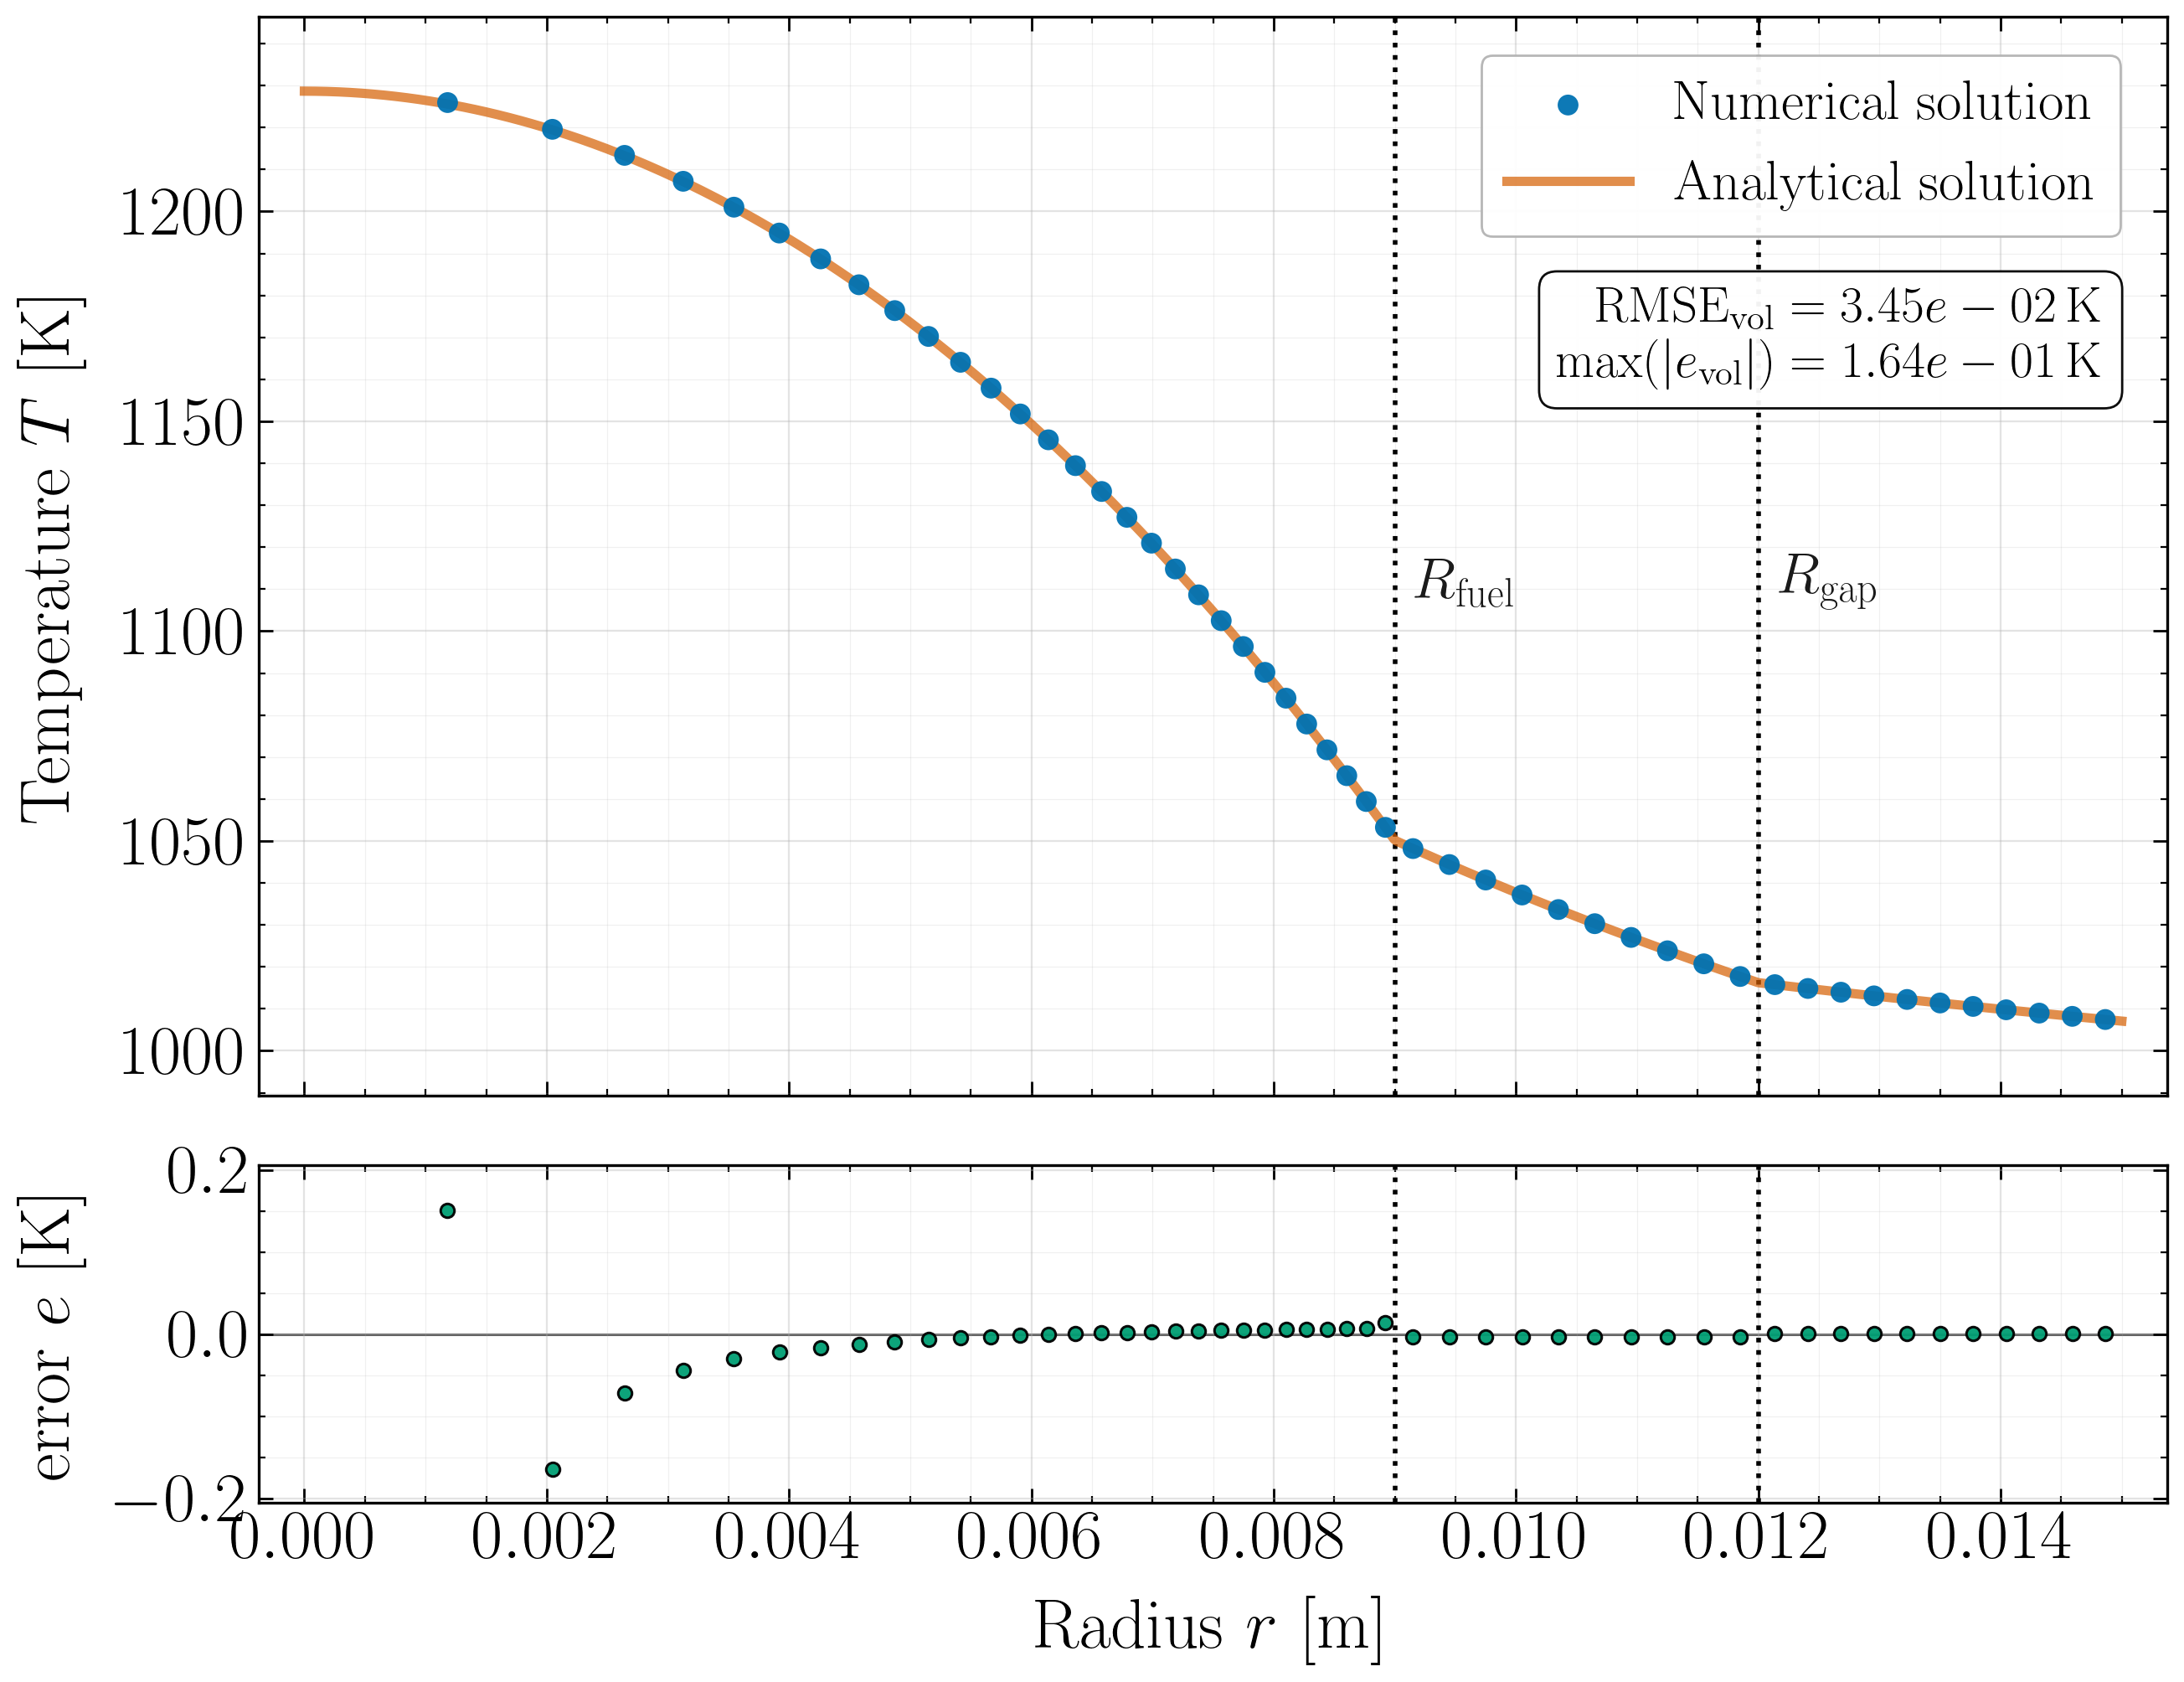

RMSE:          3.448753e-02 K
Max abs error: 1.643160e-01 K
Total power:   1.000000e+04 W
q''':          2.619834e+07 W/m^3


In [11]:
from utils.solver import Solver

solver = Solver([fuel_pin])
solver.fsolve()
T_FP, = solver.solutions[0]

fig, axes, metrics = plot_fuel_pin_layered_validation(
    fuel_pin=fuel_pin,
    cfg=cfg,
    z_idx=0,
    save_path="scripts/fuelpin/fuelpin_validation.pdf",
    show=True,
    T_numerical=T_FP
)

print(f"RMSE:          {metrics['rmse']:.6e} K")
print(f"Max abs error: {metrics['max_abs_error']:.6e} K")
print(f"Total power:   {metrics['P_total']:.6e} W")
print(f"q''':          {metrics['q_vol']:.6e} W/m^3")